# Label Alignment Test

In [20]:
from src.data import DATA_DIR_INTERIM, DATA_DIR_PROCESSED
from src.io import load_qrel_from_path, read_metadata
from topic_gen.evaluate.io import load_from_irds
from topic_gen.evaluate import MetaExperiment
from topic_gen.evaluate.measures_agreement import CohenKappa, MeanAverageError
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd

In [21]:
# input_path = DATA_DIR_INTERIM / "robust" / "qrels-topics-generated"
# irdid = "disks45/nocr/trec-robust-2004"

input_path = DATA_DIR_INTERIM / "dl19" / "qrels-topics-generated-full"
irdid = "msmarco-passage/trec-dl-2019/judged"

# input_path = DATA_DIR_INTERIM / "dl20" / "qrels-topics-generated-full"
# irdid = "msmarco-passage/trec-dl-2020/judged"
    

searcher = "GPT-OSS-120B"
judge =  "GPT-OSS-120B"
prompts = ["topic-query", "topic-query-contrastive", "topic-query-docs-pos", "topic-query-docs-neg"]


In [22]:
metadata = read_metadata(input_path)
metadata.replace({"GPT-OSS-120B-O": "GPT-OSS-120B"}, inplace=True)
metadata["topics_model"].fillna("TREC", inplace=True)

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_2147/877780177.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  metadata["topics_model"].fillna("TREC", inplace=True)


In [23]:
selected_experiments = metadata[(metadata['model'] == judge) & ((metadata['topics_model'] == searcher)) & (metadata['topics_prompt'].isin(prompts)) & (metadata['topics_nqueries'] == 1.0)]
selected_baseline = metadata[(metadata['model'] == judge) & (metadata['topics_model'] == "TREC")]
experiments_metadata = pd.concat([selected_experiments, selected_baseline])

In [24]:
experiments_metadata = experiments_metadata.fillna(0)
experiments_metadata["display_name"] = experiments_metadata.apply(
    lambda row: f"{row['topics_prompt']}-{int(float(row['topics_nqueries']))}-{int(float(row['topics_ndocspos']))}-{int(float(row['topics_ndocsneg']))}",
    axis=1,
)
name_map = experiments_metadata.set_index("name")["display_name"].to_dict()

/var/folders/pz/f66p4s0s11z2c1c1l3v0qbh40000gn/T/ipykernel_2147/508214913.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  experiments_metadata = experiments_metadata.fillna(0)


Load qrels sets

In [25]:
experiments = []

for _, row in experiments_metadata.iterrows():

    experiment, missing = load_qrel_from_path(
        input_path / row["name"],
        replace_label_mapping={999: 0},
    )
    experiments.append(experiment)

In [26]:
baseline = load_from_irds(irdid) #, binarize_level)

Evaluate

In [8]:
meta_exp = MetaExperiment(
    experiments=experiments,
    baseline=baseline,
    measures=[
        CohenKappa(),
        MeanAverageError(),
    ],
    bootstrap=20,
    filter_qrels=True,
    test="t",
    alpha=0.05,
    correction=True,
)
res = meta_exp.evaluate()

Prepare results

In [9]:
measure = "Cohens"
measure = "MAE"

In [10]:
df = pd.DataFrame(res)

In [11]:
df_pvalues = df[df["measure"].str.startswith(f"t_pvalue_{measure}")].copy()

# fix name
df_pvalues["measure"] = df_pvalues["measure"].str[-19:]
df_pvalues["measure"] = df_pvalues["measure"].map(name_map)
df_pvalues["name"] = df_pvalues["name"].map(name_map)

# prepare data
heatmap_data = df_pvalues.pivot(index="name", columns="measure", values="value")
heatmap_data = heatmap_data.apply(pd.to_numeric, errors='coerce')

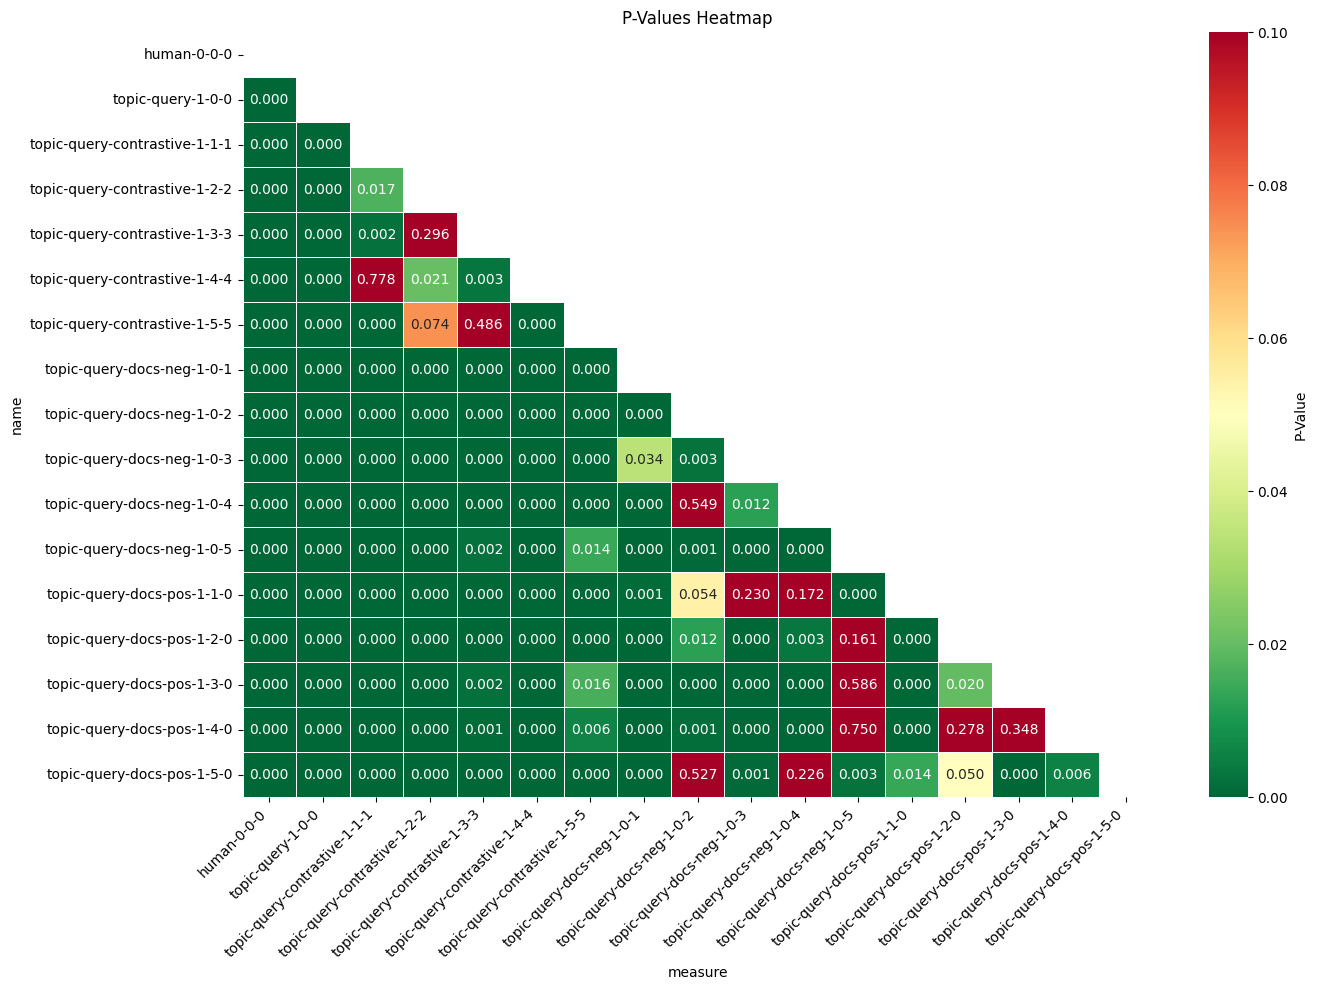

In [12]:
# Plot
mask = np.triu(np.ones_like(heatmap_data, dtype=bool)) # mask upper part

plt.figure(figsize=(14, 10))
sns.heatmap(heatmap_data, annot=True, fmt=".3f", cmap="RdYlGn_r", center=0.05, 
            vmin=0, vmax=0.1, cbar_kws={'label': 'P-Value'}, linewidths=0.5, mask=mask)

plt.title('P-Values Heatmap')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()